In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

In [2]:
# Helper functions for converting gate duration to tg*anh product
qb_anh_rads = 212.3e6 * (2 * np.pi)
def tg2prod(tg):
    return tg * (qb_anh_rads*1e-9) / (2*np.pi) #Convert anh to GHz since time on axis is in ns


def prod2tg(prod):
    return prod * (2*np.pi) / (qb_anh_rads*1e-9) #Convert anh to GHz since time on axis is in ns

(4.5, 20.0)

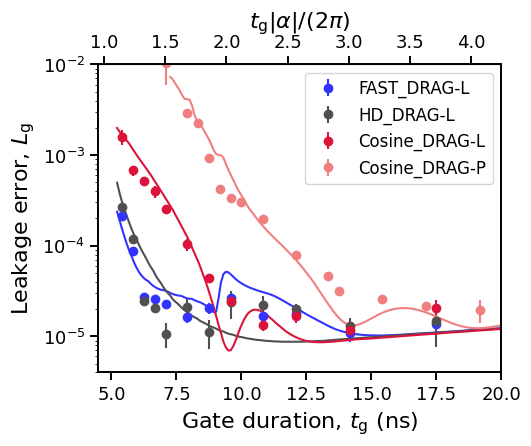

In [3]:
#Re-read csv-files and plot
pulse_names = ['FAST_DRAG-L', 'HD_DRAG-L', 'Cosine_DRAG-L', 'Cosine_DRAG-P']
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
dark_gray = [80/255, 80/255, 80/255] #[64/255, 64/255, 64/255]

colors_dict = {'FAST_DRAG-L': dark_blue, 
               'Cosine_DRAG-L': crimson,'Cosine_DRAG-P': light_red,
               'HD_DRAG-L': dark_gray, 
    }


fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    leakage_error_arr = np.genfromtxt(os.path.join(pulse, 'leakage_error_exp_arr.csv'), delimiter=',')
    leakage_error_uncertainty_arr = np.genfromtxt(os.path.join(pulse, 'leakage_error_exp_uncertainty_arr.csv'), delimiter=',')
    duration_arr = np.genfromtxt(os.path.join(pulse,'duration_exp_arr.csv'), delimiter=',')
    plt.errorbar(duration_arr*1e9, leakage_error_arr, yerr=leakage_error_uncertainty_arr, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))
    #simulations
    leakage_error_sim_arr = np.genfromtxt(os.path.join(pulse,'leakage_error_sim_arr.csv'), delimiter=',')
    duration_sim_arr = np.genfromtxt(os.path.join(pulse,'duration_sim_arr.csv'), delimiter=',')
    plt.plot(duration_sim_arr*1e9, leakage_error_sim_arr, '-', color=colors_dict[pulse])
    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'Leakage error, $L_\mathrm{g}$', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.set_yscale("log")
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([4e-6, 1e-2])
plt.xlim([4.5, 20])
